In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Parameter Ambang Batas (Disarankan oleh Jurnal Yao et al.)
# Ambang batas Otsu dimodifikasi dengan nilai ini
THRESHOLD_MODIFICATION = 10 
MIN_AREA_THRESHOLD = 1000 # Ambang batas area minimum untuk menghilangkan noise kecil (piksel)

In [33]:
def segment_image(img_rgb):
    """
    Melakukan segmentasi penyakit padi menggunakan metode klasik (Transformasi Warna + Otsu Adaptif + Morfologi).

    Langkah-langkah sesuai dengan jurnal Yao et al. (2009) yang sudah dimodifikasi:
    1. Transformasi RGB ke y1 dan y2.
    2. Thresholding Otsu pada y1/y2 untuk mendapatkan T1 dan T2.
    3. Modifikasi T untuk membuat mask biner.
    4. Penghilangan noise kecil (Area Filtering).
    5. Pengisian lubang (Hole Filling).
    6. Segmentasi akhir.
    """
    
    # Pastikan gambar dalam format BGR (standar OpenCV) dan Float
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    img_float = img_bgr.astype(np.float32)

    # Pisahkan channel B, G, R
    b, g, r = cv2.split(img_float)

    # 1. Transformasi Warna ke y1 dan y2
    # y1 = 2g - r - b, y2 = 2r - g - b (menggunakan float untuk akurasi)
    y1 = 2 * g - r - b
    # y2 = 2 * r - g - b
    
    # Normalisasi y1 dan y2 agar berada dalam rentang 0-255 untuk Otsu
    y1_norm = cv2.normalize(y1, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    # y2_norm = cv2.normalize(y2, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


    # 2. Mendapatkan Nilai Ambang Batas T1 dan T2 dari y1 dan y2 menggunakan Otsu
    # T1 dan T2 adalah ambang batas yang ditemukan Otsu
    T1, _ = cv2.threshold(y1_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # T2, _ = cv2.threshold(y2_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # 3. Melakukan Thresholding dengan Ambang Batas yang Dimodifikasi (Sesuai Formula 2 Jurnal)
    
    # Formula Jurnal (disederhanakan): Area penyakit jika (y1 < T1 + 10) DAN (y2 > T2 - 10)
    # Ini adalah logika OR yang kompleks. Kita akan menggunakan logika AND yang paling umum:
    
    # Mask 1 (dari y1): Piksel yang memenuhi y1 < T1 + 10
    # _, mask1 = cv2.threshold(y1_norm, int(T1 + THRESHOLD_MODIFICATION), 255, cv2.THRESH_BINARY_INV)
    _, mask_binary = cv2.threshold(y1_norm, int(T1 + THRESHOLD_MODIFICATION), 255, cv2.THRESH_BINARY_INV)
    
    # Mask 2 (dari y2): Piksel yang memenuhi y2 > T2 - 10
    # Catatan: T2 adalah ambang batas untuk memisahkan objek dari latar belakang,
    # penggunaan THRESH_BINARY di sini akan membuat piksel > T2-10 menjadi putih
    # _, mask2 = cv2.threshold(y2_norm, int(T2 - THRESHOLD_MODIFICATION), 255, cv2.THRESH_BINARY)
    
    # Gabungkan kedua mask: Hanya area yang memenuhi KEDUA kondisi yang menjadi putih
    # mask_binary = cv2.bitwise_and(mask1, mask2)


    # 4. Penghilangan Noise Kecil (Area Filtering)
    # Temukan kontur dan hapus yang terlalu kecil
    contours, _ = cv2.findContours(mask_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask_cleaned = np.zeros_like(mask_binary)
    
    for contour in contours:
        area = cv2.contourArea(contour)
        if area > MIN_AREA_THRESHOLD:
            # Isi area yang cukup besar
            cv2.drawContours(mask_cleaned, [contour], -1, 255, thickness=cv2.FILLED)

    # 5. Pengisian Lubang (Hole Filling)
    # Operasi Morphological Closing (menutup celah dan mengisi lubang)
    kernel_close = np.ones((7, 7), np.uint8) # Gunakan kernel agak besar
    mask_filled = cv2.morphologyEx(mask_cleaned, cv2.MORPH_CLOSE, kernel_close)
    # mask_filled = cv2.bitwise_not(mask_filled)

    # 6. Deteksi Tepi (Opsional, untuk fitur bentuk)
    # Tepi (kontur) dari area penyakit yang sudah bersih
    final_contours, _ = cv2.findContours(mask_filled, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # 7. Mensegmentasi Gambar Asli
    # Terapkan mask akhir (mask_filled) ke gambar RGB asli
    # Konversi kembali ke format BGR untuk operasi bitwise and
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    mask_3_channel = cv2.cvtColor(mask_filled, cv2.COLOR_GRAY2BGR)
    segmented_img_bgr = cv2.bitwise_and(img_bgr, mask_3_channel)

    return segmented_img_bgr

Text(0.5, 1.0, 'B Channel')

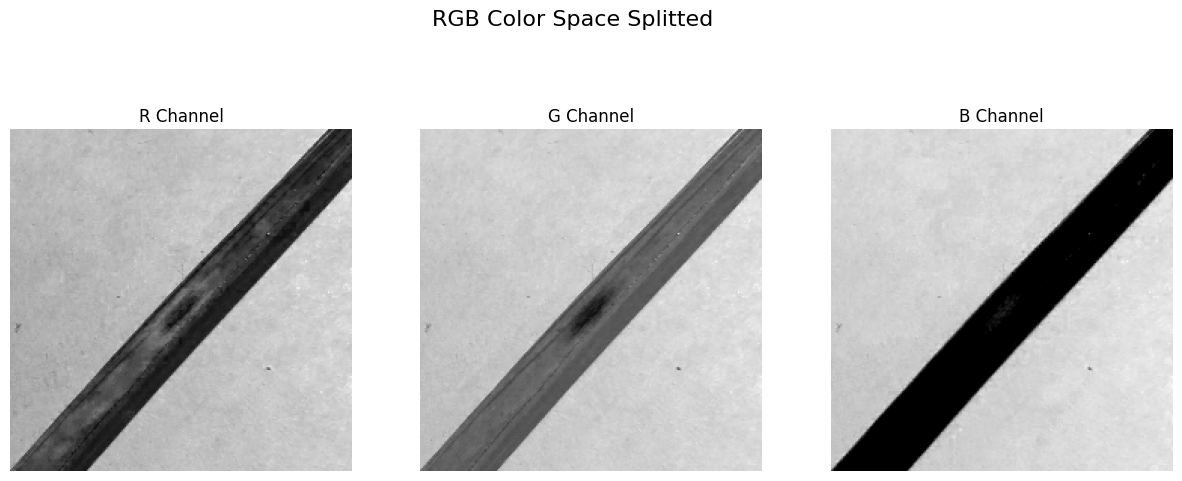

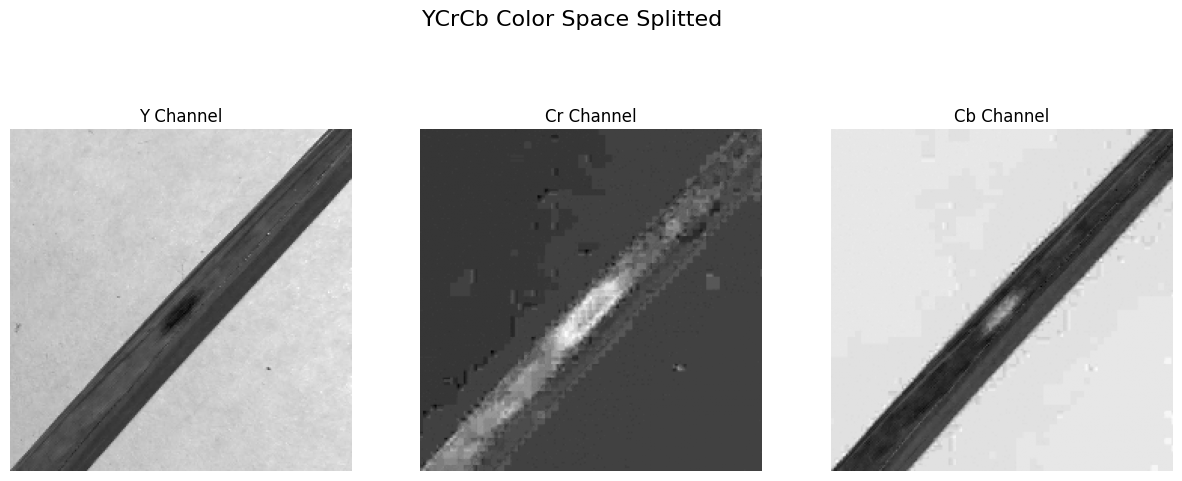

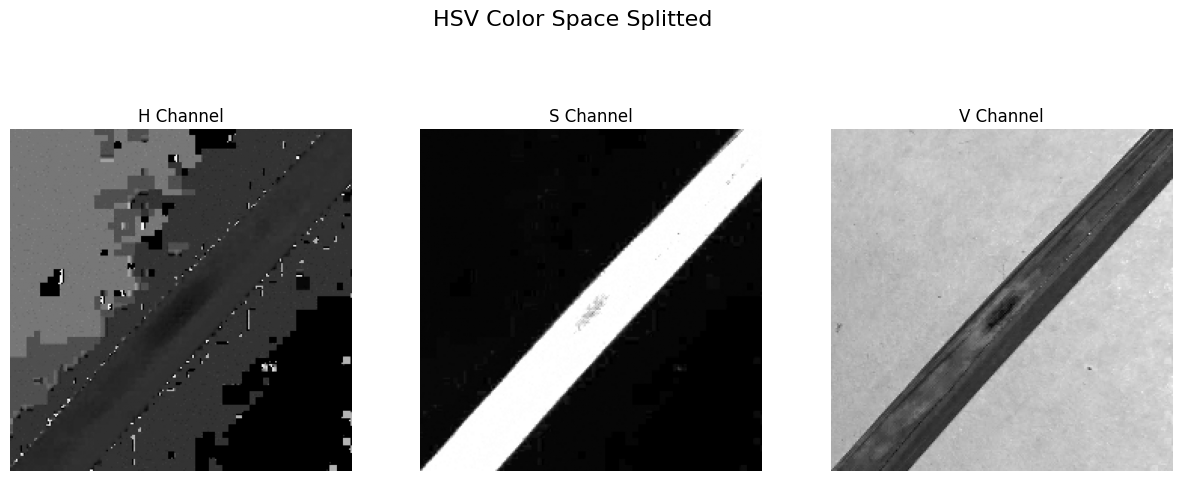

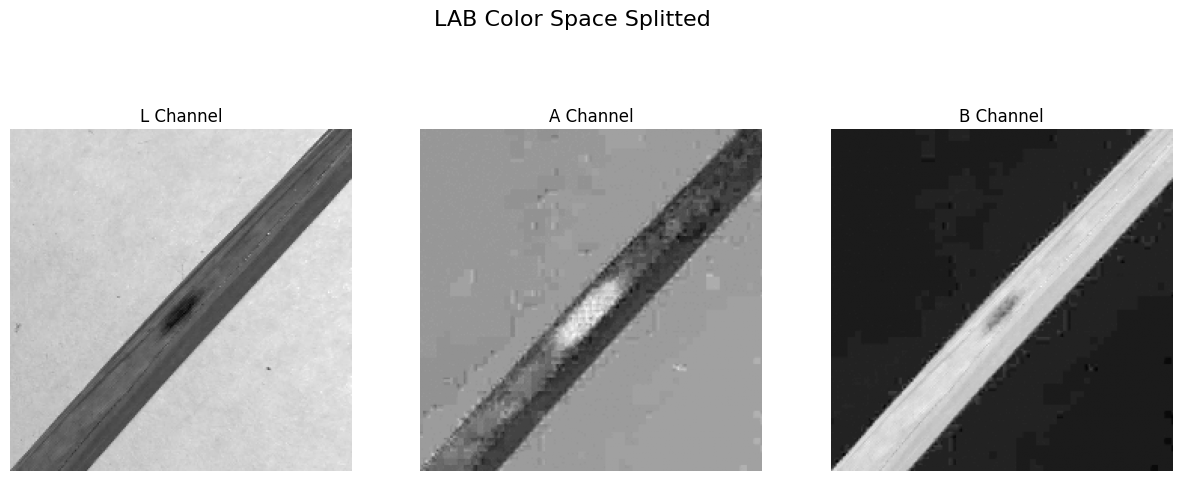

In [43]:
IMG_SIZE = (227, 227)
label = 'normal'
img = cv2.resize(cv2.imread('datasets/Rice Diseases Image Dataset/train/brown_spot.jpg'), IMG_SIZE)

fig = plt.figure(figsize=(15, 6))

fig.suptitle('RGB Color Space Splitted', fontsize=16)

fig.add_subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)[:,:,0], cmap='gray')
plt.axis('off') 
plt.title("R Channel")

fig.add_subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)[:,:,1], cmap='gray')
plt.axis('off') 
plt.title("G Channel")

fig.add_subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)[:,:,2], cmap='gray')
plt.axis('off') 
plt.title("B Channel")

fig = plt.figure(figsize=(15, 6))

fig.suptitle('YCrCb Color Space Splitted', fontsize=16)

fig.add_subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)[:,:,0], cmap='gray')
plt.axis('off') 
plt.title("Y Channel")

fig.add_subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)[:,:,1], cmap='gray')
plt.axis('off') 
plt.title("Cr Channel")

fig.add_subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)[:,:,2], cmap='gray')
plt.axis('off') 
plt.title("Cb Channel")

fig = plt.figure(figsize=(15, 6))

fig.suptitle('HSV Color Space Splitted', fontsize=16)

fig.add_subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2HSV)[:,:,0], cmap='gray')
plt.axis('off') 
plt.title("H Channel")

fig.add_subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2HSV)[:,:,1], cmap='gray')
plt.axis('off') 
plt.title("S Channel")

fig.add_subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2HSV)[:,:,2], cmap='gray')
plt.axis('off') 
plt.title("V Channel")

fig = plt.figure(figsize=(15, 6))

fig.suptitle('LAB Color Space Splitted', fontsize=16)

fig.add_subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2LAB)[:,:,0], cmap='gray')
plt.axis('off') 
plt.title("L Channel")

fig.add_subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2LAB)[:,:,1], cmap='gray')
plt.axis('off') 
plt.title("A Channel")

fig.add_subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2LAB)[:,:,2], cmap='gray')
plt.axis('off') 
plt.title("B Channel")

(227, 227, 3)


Text(0.5, 1.0, 'normal')

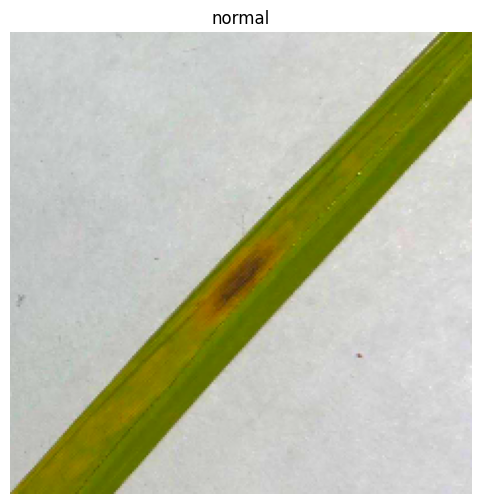

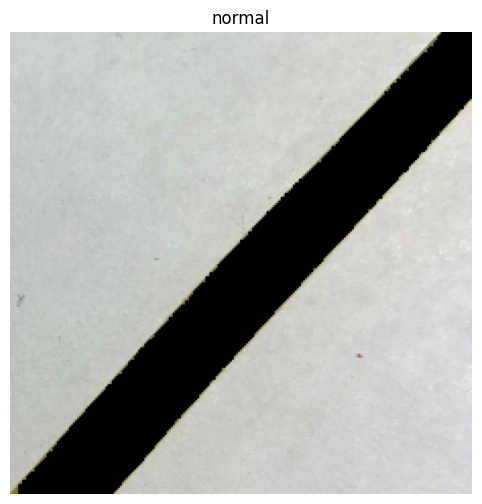

In [44]:
print(img.shape)
segmented_image = segment_image(img)

fig = plt.figure(figsize=(9, 6))

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off') 
plt.title(label)

fig = plt.figure(figsize=(9, 6))

plt.imshow(segmented_image, cmap='gray')
plt.axis('off') 
plt.title(label)

(227, 227, 3)


Text(0.5, 1.0, 'brown_spot')

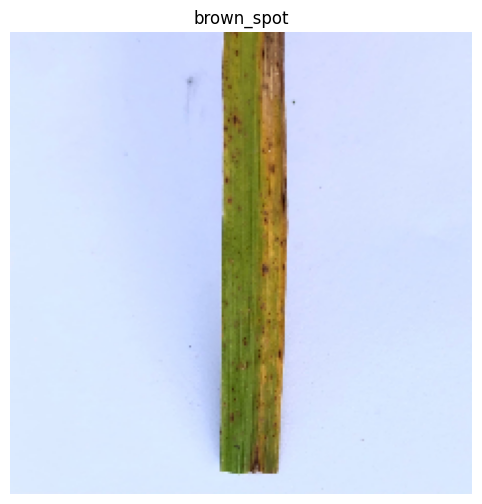

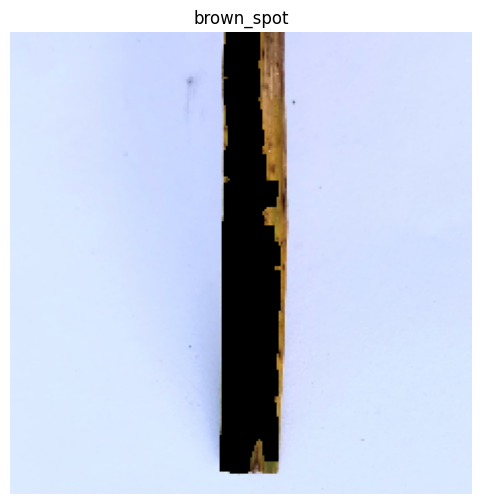

In [45]:
IMG_SIZE = (227, 227)
label = 'brown_spot'
img = cv2.resize(cv2.imread('datasets/leaf-rice-disease-indonesia/tungro/IMG_0872.jpg'), IMG_SIZE)
print(img.shape)
segment_image2 = segment_image(img)

fig = plt.figure(figsize=(9, 6))

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off') 
plt.title(label)

fig = plt.figure(figsize=(9, 6))

plt.imshow(segment_image2, cmap='gray')
plt.axis('off') 
plt.title(label)